# Lab 22 - AutoEncoders

In [3]:
import torch
import torch.nn as nn
import torch.utils.data as data
from torchvision import datasets, transforms
import numpy as np
import math
import networkx as nx
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [38]:

# Utilities to print out samples

@torch.no_grad()
def visualize_reconstructions(model, loader, n=8):
    """ Visualize original and reconstructed images side by side."""
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)
    x_hat = model(x).cpu()
    x = x.cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))
    for i in range(n):
        axes[0, i].imshow(x[i, 0], cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(x_hat[i, 0], cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_title("Original", fontsize=10)
    axes[1, 0].set_title("Reconstruction", fontsize=10)
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def visualize_denoise(model, loader, corruption_fn, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)[:n]
    x_noisy = corruption_fn(x)
    with torch.no_grad():
        x_hat = model(x_noisy)
    x = x.cpu(); x_noisy = x_noisy.cpu(); x_hat = x_hat.cpu()

    fig, axes = plt.subplots(3, n, figsize=(1.5*n, 4))
    for i in range(n):
        axes[0, i].imshow(x[i,0], cmap='gray'); axes[0,i].axis('off')
        axes[1, i].imshow(x_noisy[i,0], cmap='gray'); axes[1,i].axis('off')
        axes[2, i].imshow(x_hat[i,0], cmap='gray'); axes[2,i].axis('off')
    axes[0,0].set_ylabel("Clean")
    axes[1,0].set_ylabel("Noisy")
    axes[2,0].set_ylabel("Denoised")
    plt.tight_layout(); plt.show()

@torch.no_grad()
def visualize_samples(loader, num_samples=6): 
    """ Visualize a few samples from the dataset.
    """
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples*1.5, 2))
    for i in range(num_samples):
        axes[i].imshow(images[i][0], cmap="gray")
        axes[i].set_title(str(labels[i].item()))
        axes[i].axis("off")
    plt.show()

In [17]:
transform = transforms.ToTensor()  # pixels in [0,1]
batch_size = 64
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# data loaders
train_loader = data.DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = data.DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

In [16]:
print(next(iter(train_loader))[0].shape) # Input shape: batchx1x28x28
print(next(iter(train_loader))[1].shape) # Output shape: batch

torch.Size([128, 1, 28, 28])
torch.Size([128])


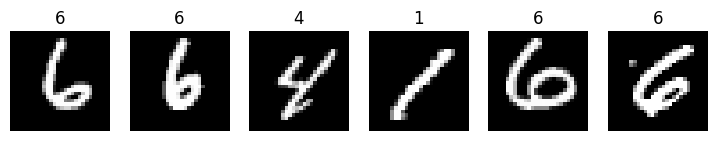

In [6]:
visualize_samples(train_loader)

## Ex. 1) Non-Linear AutoEncoder

In [ ]:
class DeepAE(nn.Module):

    def __init__(self, n_latent):
        super().__init__()
        self.encoder = nn.Sequential( # MNIST Images are 28x28
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, n_latent)
        )
        self.decoder = nn.Sequential(
            nn.Linear(n_latent, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = x.view(x.size(0), -1) # Flattening di tutto meno che il batch (dim=0), -1 è equiv. a 1*28*28
        return self.encoder(x)

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28) # Restoring the 1x28x28 for each image, keeping batch

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat

model = DeepAE(n_latent=64).to(device)    
    
EPOCHS = 3
LR = 1E-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_function = nn.MSELoss() # Reconstruction loss

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    # Train Epoch
    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()
        x, _ = batch
        x = x.to(device)
        
        x_hat = model(x)
        loss = loss_function(x_hat, x)
        train_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    # Eval Epoch
    model.eval()
    with torch.no_grad():
        eval_loss = 0.0
        
        for i, batch in enumerate(test_loader):
            x, _ = batch
            x = x.to(device)
            x_hat = model(x)
            loss = loss_function(x_hat, x)
            eval_loss += loss.item()
            
    print(f"Epoch {epoch:3d} | Train Loss {train_loss:4.3f} | Test Loss {eval_loss:4.3f}")

Epoch   0 | Train Loss 18.340 | Test Loss 1.385
Epoch   1 | Train Loss 6.641 | Test Loss 0.878
Epoch   2 | Train Loss 4.707 | Test Loss 0.665


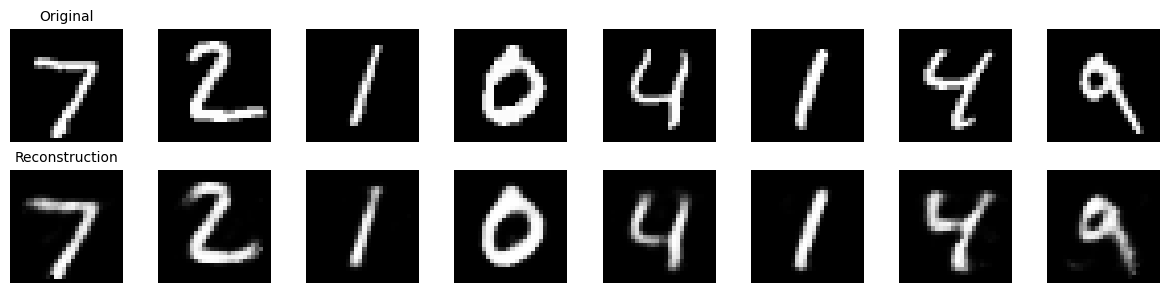

In [26]:
visualize_reconstructions(model, test_loader, n=8)

## Ex. 2) Convolutional AutoEncoder

In [59]:
class ConvAE(nn.Module):
    
    # Remember: 
    # CONV2D: D_out = (D_in + 2 * padding - (kernel)) / stride + 1
    # CONVTRANSPOSE2D: D_out = (D_in - 1) * stride - 2 * padding + kernel + output_padding

    def __init__(self, n_latent):
        super().__init__()
        self.encoder = nn.Sequential( # MNIST Images are 28x28
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=2, padding=1), # 14x14 
            nn.ReLU(),
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=2, padding=1), # 7x7
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=n_latent, kernel_size=3, stride=1, padding=1), # 7x7
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=n_latent, out_channels=16, kernel_size=3, stride=1, padding=1), # 7x7
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=16, out_channels=8, kernel_size=3, stride=2, padding=1, output_padding=1), # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=8, out_channels=1, kernel_size=3, stride=2, padding=1, output_padding=1), # 14x14 
            nn.Sigmoid()
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat

model = ConvAE(n_latent=32).to(device)    
    
EPOCHS = 3
LR = 1E-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_function = nn.BCELoss() # Reconstruction loss - BCE recommended if we end with a sigmoid apparently

for epoch in range(EPOCHS):
    train_loss = 0.0
    
    # Train Epoch
    model.train()
    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()
        x, _ = batch
        x = x.to(device)
        
        x_hat = model(x)
        loss = loss_function(x_hat, x)
        train_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    # Eval Epoch
    model.eval()
    with torch.no_grad():
        eval_loss = 0.0
        
        for i, batch in enumerate(test_loader):
            x, _ = batch
            x = x.to(device)
            x_hat = model(x)
            loss = loss_function(x_hat, x)
            eval_loss += loss.item()
            
    print(f"Epoch {epoch:3d} | Train Loss {train_loss:4.3f} | Test Loss {eval_loss:4.3f}")

Epoch   0 | Train Loss 84.705 | Test Loss 6.416
Epoch   1 | Train Loss 36.065 | Test Loss 5.734
Epoch   2 | Train Loss 33.606 | Test Loss 5.504


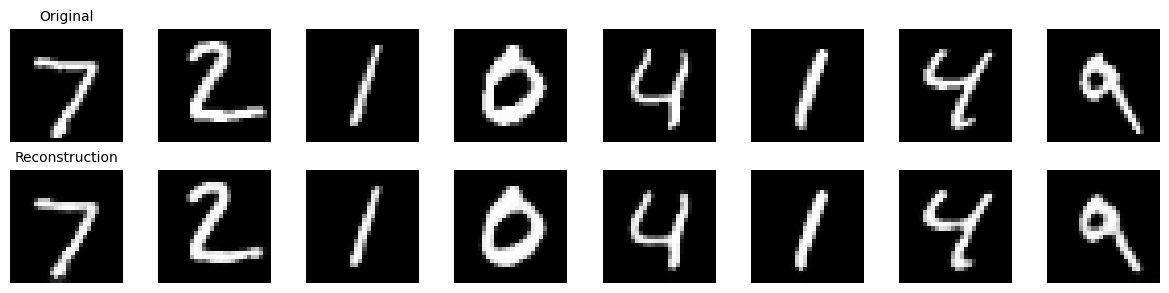

In [60]:
visualize_reconstructions(model, test_loader, n=8)

## Ex. 3) Denoising Autoencoder

In [61]:
# We can use the same AE as before, but this time we introduce noise in the training

def add_gaussian_noise(x, sigma=0.2):
    """x in [0,1] -> clip to [0,1]"""
    return torch.clamp(x + sigma*torch.randn_like(x), 0.0, 1.0)

model = ConvAE(n_latent=32).to(device)    
    
EPOCHS = 15
LR = 1E-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_function = nn.MSELoss() # Reconstruction loss - BCE recommended if we end with a sigmoid apparently

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    # Train Epoch
    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()
        x, _ = batch
        x = x.to(device)
        x_noisy = add_gaussian_noise(x)
        
        x_hat = model(x_noisy)
        loss = loss_function(x_hat, x)
        train_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    # Eval Epoch
    model.eval()
    with torch.no_grad():
        eval_loss = 0.0
        
        for i, batch in enumerate(test_loader):
            x, _ = batch
            x = x.to(device)
            x_noisy = add_gaussian_noise(x)
            x_hat = model(x_noisy)
            loss = loss_function(x_hat, x)
            eval_loss += loss.item()
            
    print(f"Epoch {epoch:3d} | Train Loss {train_loss:4.3f} | Test Loss {eval_loss:4.3f}")

Epoch   0 | Train Loss 55.387 | Test Loss 9.030
Epoch   1 | Train Loss 52.529 | Test Loss 9.030
Epoch   2 | Train Loss 52.530 | Test Loss 9.030
Epoch   3 | Train Loss 52.528 | Test Loss 9.030
Epoch   4 | Train Loss 52.530 | Test Loss 9.030
Epoch   5 | Train Loss 52.528 | Test Loss 9.030
Epoch   6 | Train Loss 52.529 | Test Loss 9.030
Epoch   7 | Train Loss 52.530 | Test Loss 9.030
Epoch   8 | Train Loss 52.530 | Test Loss 9.030
Epoch   9 | Train Loss 52.529 | Test Loss 9.030
Epoch  10 | Train Loss 52.531 | Test Loss 9.030
Epoch  11 | Train Loss 52.529 | Test Loss 9.030
Epoch  12 | Train Loss 52.530 | Test Loss 9.030
Epoch  13 | Train Loss 52.528 | Test Loss 9.030
Epoch  14 | Train Loss 52.528 | Test Loss 9.030


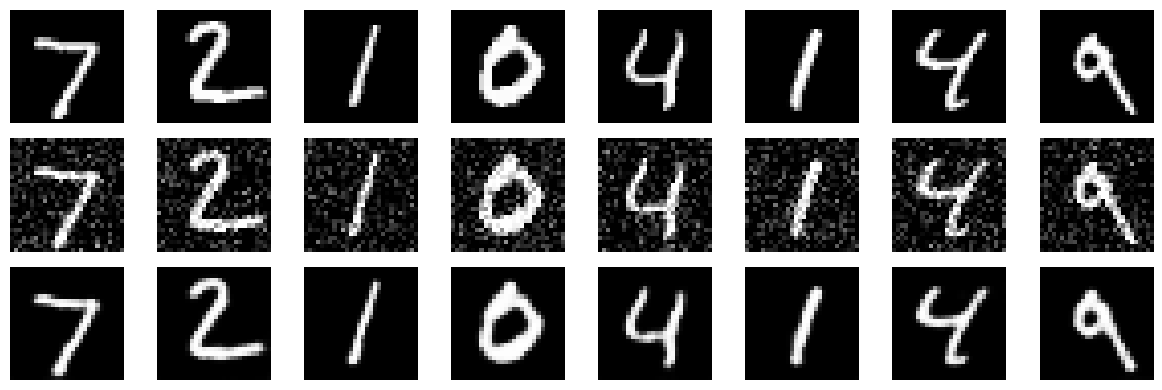

In [55]:
visualize_denoise(model, test_loader, add_gaussian_noise, n=8)

## Ex. 4) Variational Autoencoder

In [63]:
class VariationalAE(nn.Module):
    
    # Remember: D_out = (D_in + 2 * padding - (kernel)) / stride + 1

    def __init__(self, n_input, n_hidden, n_latent):
        super().__init__()
        self.encoder = nn.Sequential( # MNIST Images are 28x28
            nn.Linear(n_input, n_hidden),
            nn.ReLU(inplace=True),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(inplace=True),
        )
        self.fc_mu = nn.Linear(n_hidden, n_latent)
        self.fc_logvar = nn.Linear(n_hidden, n_latent)
        self.decoder = nn.Sequential(
            nn.Linear(n_latent, n_hidden),
            nn.ReLU(inplace=True),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(inplace=True),
            nn.Linear(n_hidden, n_input),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten except for batch
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar

model = VariationalAE(n_input=28*28, n_hidden=400, n_latent=20).to(device)    
    
EPOCHS = 10
LR = 1E-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
bce_loss_function = nn.BCEWithLogitsLoss(reduction='sum') # Reconstruction loss

def elbo_loss(x, logits, mu, logvar):
    # 1st Term: Reconstruction
    recon = bce_loss_function(logits, x)
    # 2nd Term: KL(q||p) with q=N(mu, diag(sigma^2)), p=N(0,I)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl, recon, kl

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    # Train Epoch
    for i, (x, _) in enumerate(train_loader):
        optimizer.zero_grad()
        x = x.to(device)
        x_flat = x.view(x.size(0), -1)
        
        logits, mu, logvar = model(x)
        loss, _, _ = elbo_loss(x_flat, logits, mu, logvar)
        train_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    # Eval Epoch
    model.eval()
    with torch.no_grad():
        eval_loss = 0.0
        
        for i, (x, _) in enumerate(test_loader):
            x = x.to(device)
            x_flat = x.view(x.size(0), -1)
            logits, mu, logvar = model(x)
            loss, _, _ = elbo_loss(x_flat, logits, mu, logvar)
            eval_loss += loss.item()
            
    print(f"Epoch {epoch:3d} | Train Loss {train_loss:4.3f} | Test Loss {eval_loss:4.3f}")

Epoch   0 | Train Loss 10604433.955 | Test Loss 1371456.914
Epoch   1 | Train Loss 7674010.303 | Test Loss 1195790.763
Epoch   2 | Train Loss 7031022.134 | Test Loss 1136706.913
Epoch   3 | Train Loss 6771003.924 | Test Loss 1109931.070
Epoch   4 | Train Loss 6613171.733 | Test Loss 1086150.467
Epoch   5 | Train Loss 6496517.944 | Test Loss 1072595.541
Epoch   6 | Train Loss 6404650.046 | Test Loss 1055750.860
Epoch   7 | Train Loss 6326464.984 | Test Loss 1048219.132
Epoch   8 | Train Loss 6272217.778 | Test Loss 1039619.806
Epoch   9 | Train Loss 6215543.564 | Test Loss 1032346.728


In [72]:
# For visualization

@torch.no_grad()
def show_reconstructions(model, loader, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)[:n]
    logits, mu, logvar = model(x)
    x_hat = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()
    x = x.cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))
    for i in range(n):
        axes[0, i].imshow(x[i,0], cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(x_hat[i,0], cmap="gray"); axes[1, i].axis("off")
    axes[0,0].set_title("Original", fontsize=10)
    axes[1,0].set_title("Reconstruction", fontsize=10)
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def sample_from_prior(model, n=32):
    model.eval()
    z = torch.randn(n, 20, device=device)
    logits = model.decode(z)
    x = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(4, 8, figsize=(8, 4))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(x[i,0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def interpolate_two(model, dataset, n_steps=10):
    model.eval()
    idx = torch.randint(0, len(dataset), (2,))
    x0, _ = dataset[idx[0].item()]
    x1, _ = dataset[idx[1].item()]
    x0 = x0.unsqueeze(0).to(device)
    x1 = x1.unsqueeze(0).to(device)

    mu0, logvar0 = model.encode(x0.view(1, -1))
    mu1, logvar1 = model.encode(x1.view(1, -1))
    # use means for deterministic interpolation
    z0, z1 = mu0.squeeze(0), mu1.squeeze(0)

    alphas = torch.linspace(0, 1, n_steps, device=device)
    imgs = []
    for a in alphas:
        z = (1-a)*z0 + a*z1
        logits = model.decode(z.unsqueeze(0))
        imgs.append(torch.sigmoid(logits).view(28,28).cpu().numpy())

    fig, axes = plt.subplots(1, n_steps+2, figsize=(1.2*(n_steps+2), 2))
    axes[0].imshow(x0.cpu()[0,0], cmap="gray"); axes[0].axis("off"); axes[0].set_title("x")
    for i,a in enumerate(alphas):
        axes[i+1].imshow(imgs[i], cmap="gray"); axes[i+1].axis("off"); axes[i+1].set_title(f"{a.item():.1f}", fontsize=8)
    axes[-1].imshow(x1.cpu()[0,0], cmap="gray"); axes[-1].axis("off"); axes[-1].set_title("x'")
    plt.tight_layout()
    plt.show()

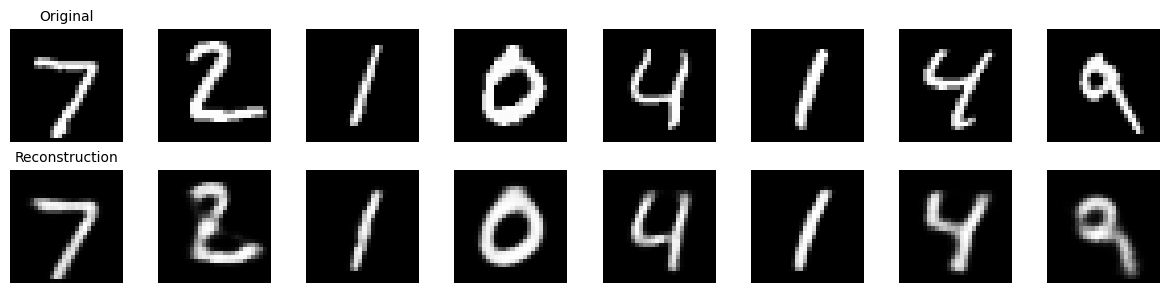

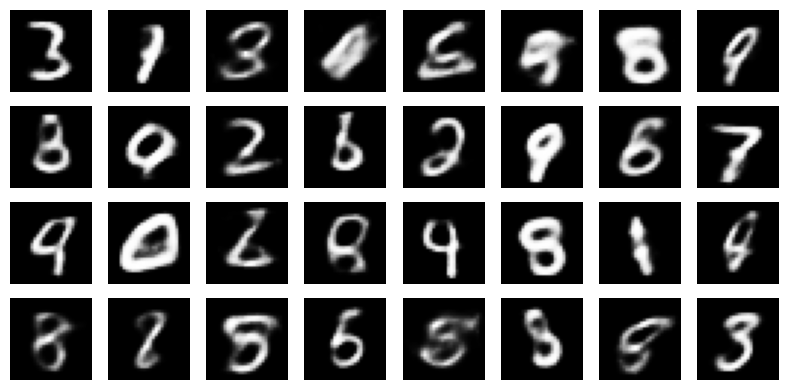

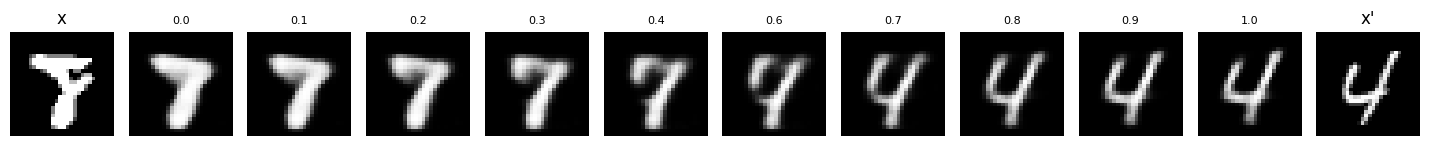

In [73]:
show_reconstructions(model, test_loader, n=8)
sample_from_prior(model, n=32)
interpolate_two(model, test_ds, n_steps=10)